<a href="https://colab.research.google.com/github/kuruvajayanth12/Neural-Networks-and-Deep-Learning/blob/main/NNDL_EXP4_AMS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
pip install face_recognition opencv-python numpy pandas


In [9]:
import cv2
import face_recognition
import numpy as np
import pandas as pd
import pickle
import os
from datetime import datetime
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64

NAME = "Jayanth"
ENCODING_FILE = "encodings.pkl"
ATTENDANCE_FILE = "attendance.csv"

# Load previous encodings
if os.path.exists(ENCODING_FILE):
    with open(ENCODING_FILE, "rb") as f:
        data = pickle.load(f)
        known_encodings = data["encodings"]
        known_names = data["names"]
else:
    known_encodings = []
    known_names = []

# Create attendance file
if not os.path.exists(ATTENDANCE_FILE):
    df = pd.DataFrame(columns=["Name", "Time"])
    df.to_csv(ATTENDANCE_FILE, index=False)

# Camera capture function
def capture_image():
    js = Javascript('''
    async function takePhoto() {
      const video = document.createElement('video');
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => setTimeout(resolve, 2000));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      video.remove();

      return canvas.toDataURL('image/jpeg');
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')

    img_bytes = base64.b64decode(data.split(',')[1])
    np_arr = np.frombuffer(img_bytes, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

    return img

In [21]:
name = input("Enter person's name: ")

frame = capture_image()

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
encodings = face_recognition.face_encodings(rgb)

if len(encodings) > 0:
    known_encodings.append(encodings[0])
    known_names.append(name)

    with open(ENCODING_FILE, "wb") as f:
        pickle.dump({"encodings": known_encodings, "names": known_names}, f)

    print(f"✅ Face trained for {name}")

else:
    print("❌ No face detected")



Enter person's name: aryan


<IPython.core.display.Javascript object>

✅ Face trained for aryan


<IPython.core.display.Javascript object>

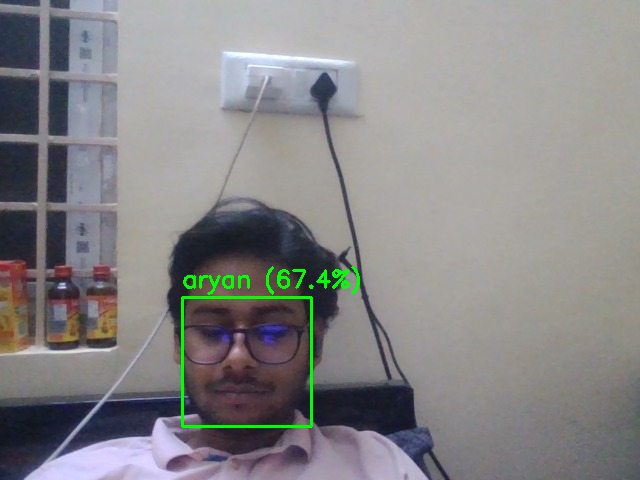

In [22]:
frame = capture_image()

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

face_locations = face_recognition.face_locations(rgb)
face_encodings = face_recognition.face_encodings(rgb, face_locations)

marked_names = set()

for encoding, location in zip(face_encodings, face_locations):

    name = "Unknown"

    if len(known_encodings) > 0:
        face_distances = face_recognition.face_distance(known_encodings, encoding)

        best_match_index = np.argmin(face_distances)
        min_distance = face_distances[best_match_index]

        # STRICT threshold (important)
        if min_distance < 0.5:
            name = known_names[best_match_index]

            # Mark attendance only once
            if name not in marked_names:
                now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                new_entry = pd.DataFrame([[name, now]], columns=["Name", "Time"])
                new_entry.to_csv(ATTENDANCE_FILE, mode='a', header=False, index=False)
                marked_names.add(name)

        # Optional confidence
        confidence = round((1 - min_distance) * 100, 2)
        display_name = f"{name} ({confidence}%)"
    else:
        display_name = "No Data"

    # Draw box
    top, right, bottom, left = location
    cv2.rectangle(frame, (left, top), (right, bottom), (0,255,0), 2)
    cv2.putText(frame, display_name, (left, top-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

from google.colab.patches import cv2_imshow
cv2_imshow(frame)